# Semana 01 · AgentOps y LLMOps con MLflow

Práctica guiada para observar trazas y evaluación mínima sin depender de un proveedor LLM. Usaremos un agente determinista para aprender el flujo: entrada → ruta → contexto → respuesta → traza → evaluación.


## 0. Dependencias y configuración

Deja `USE_LLM = False`. El objetivo es instrumentar y evaluar, no llamar a un modelo externo.


In [8]:
%pip install -q --upgrade "mlflow[databricks]"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import json
from typing import Any

import mlflow

USE_LLM = False
AGENT_VERSION = "v1-deterministic"
EXPERIMENT_NAME = "/Shared/muiaap-operacion-modelos/semana01-agentops"
mlflow.set_experiment(EXPERIMENT_NAME)
# mlflow.set_tags fuera de un run abre un run automaticamente y luego start_run da error
# porque ya hay uno activo, asi que pongo los tags dentro del run de evaluacion, sino m da error en la seccion 4
TAGS = {"course": "operacion-modelos", "week": "01", "agent.version": AGENT_VERSION}

## 1. Trazar un agente sencillo

**TODO 1:** completa las reglas de ruta, recuperación y respuesta. Decide qué palabras activan cada ruta, porque esa decisión define el comportamiento observable. Inspecciona `@mlflow.trace`. Verifica que cada pregunta devuelve texto y que en MLflow aparecen spans anidados.


In [10]:
@mlflow.trace
def route_question(question: str) -> str:
    text = question.lower()
    if any(word in text for word in ["token", "secreto", "contraseña", "password", "clave", "privacidad", "correo"]):
        return "security"
    if any(word in text for word in ["producción", "produccion", "api", "servicio", "desplegar", "despliegue"]):
        return "production"
    return "mlflow"


@mlflow.trace
def retrieve_course_context(topic: str) -> str:
    contexts = {
        "security": "No registres secretos en parámetros, tags ni artefactos.",
        "production": "En producción importan contratos, versionado y monitorización.",
        "mlflow": "Un experimento agrupa runs con parámetros, métricas y artefactos.",
    }
    return contexts[topic]


@mlflow.trace
def course_agent(question: str) -> str:
    route = route_question(question)
    context = retrieve_course_context(route)
    # tags en la traza para poder buscarla despues por version y ruta
    mlflow.update_current_trace(tags={"agent.version": AGENT_VERSION, "agent.route": route})
    return f"Ruta: {route}. {context}"

questions = [
    "¿Qué objeto agrupa varios runs?",
    "¿Puedo pegar mi token en un parámetro de MLflow?",
    "¿Qué cambia cuando llevo un modelo a producción?",
]
answers = [{"question": q, "answer": course_agent(q)} for q in questions]
display(answers)
assert all("Ruta:" in item["answer"] for item in answers)

[{'question': '¿Qué objeto agrupa varios runs?',
  'answer': 'Ruta: mlflow. Un experimento agrupa runs con parámetros, métricas y artefactos.'},
 {'question': '¿Puedo pegar mi token en un parámetro de MLflow?',
  'answer': 'Ruta: security. No registres secretos en parámetros, tags ni artefactos.'},
 {'question': '¿Qué cambia cuando llevo un modelo a producción?',
  'answer': 'Ruta: production. En producción importan contratos, versionado y monitorización.'}]

## 2. Inspeccionar una traza

En **Experiments**, abre una traza de `course_agent`. Anota qué ruta siguió la pregunta, qué contexto recuperó y qué cambiarías si una ruta fuese incorrecta.

En la traza de la pregunta del token se ve el span course_agent y dentro route_questio y retrieve_course_context (devuelve la frase de no registrar secretos). Si la ruta fuese incorrecta el error estaría en route_question, en las palabras clave, porque el contexto solo depende de la ruta. Lo arreglaría añadiendo palabras o cambiando el orden de los if.


## 3. Evaluación mínima y transparente

No usamos un juez LLM. Comprobamos una expectativa simple: que la respuesta contenga una palabra esperada.

**TODO 2:** añade al menos dos casos: uno de privacidad/secretos y otro de producción. Importa porque la evaluación debe cubrir comportamientos relevantes. Inspecciona listas de diccionarios y verifica que `evaluation_df` tiene todos los casos.


In [11]:
EVALUATION_DATA = [
    {"question": "¿Qué objeto agrupa varios runs?", "must_include": "experimento"},
    {"question": "¿Puedo guardar una contraseña como tag?", "must_include": "secretos"},
    {"question": "¿Qué debo cuidar en producción?", "must_include": "contratos"},
    {"question": "¿Puedo poner la clave de la base de datos en un artefacto?", "must_include": "secretos"},
    {"question": "¿Qué hay que tener en cuenta al desplegar una API?", "must_include": "versionado"},
]

evaluation_rows = []
for case in EVALUATION_DATA:
    answer = course_agent(case["question"])
    passed = case["must_include"].lower() in answer.lower()
    evaluation_rows.append({**case, "answer": answer, "passed": passed})

evaluation_df = __import__("pandas").DataFrame(evaluation_rows)
display(evaluation_df)
assert len(evaluation_df) == len(EVALUATION_DATA)
assert evaluation_df["passed"].all(), "Alguna expectativa mínima no se cumple"

,question,must_include,answer,passed
0,¿Qué objeto agrupa varios runs?,experimento,Ruta: mlflow. Un experimento agrupa runs con p...,True
1,¿Puedo guardar una contraseña como tag?,secretos,Ruta: security. No registres secretos en parám...,True
2,¿Qué debo cuidar en producción?,contratos,Ruta: production. En producción importan contr...,True
3,¿Puedo poner la clave de la base de datos en u...,secretos,Ruta: security. No registres secretos en parám...,True
4,¿Qué hay que tener en cuenta al desplegar una ...,versionado,Ruta: production. En producción importan contr...,True


## 4. Registrar un run de evaluación

**TODO 3:** registra el número de casos y el porcentaje que pasa. Importa porque una evaluación sin run se pierde. Inspecciona `mlflow.log_metric` y `mlflow.log_dict`. Verifica que el run contiene el artefacto `evaluation/results.json`.


In [12]:
with mlflow.start_run(run_name=f"agent-evaluation-{AGENT_VERSION}") as run:
    mlflow.set_tags(TAGS)
    mlflow.set_tags({"agent.version": AGENT_VERSION, "purpose": "guided-agentops-evaluation"})
    mlflow.log_param("case_count", len(evaluation_df))
    mlflow.log_metric("case_count", len(evaluation_df))
    mlflow.log_metric("pass_rate", float(evaluation_df["passed"].mean()))
    mlflow.log_dict(evaluation_rows, "evaluation/results.json")
    EVALUATION_RUN_ID = run.info.run_id

print({"evaluation_run_id": EVALUATION_RUN_ID, "pass_rate": float(evaluation_df["passed"].mean())})

# compruebo que el artefacto esta en el run
artifacts = [a.path for a in mlflow.MlflowClient().list_artifacts(EVALUATION_RUN_ID, "evaluation")]
print(artifacts)
assert "evaluation/results.json" in artifacts


{'evaluation_run_id': '2bff4be8d77743ac86bc05fb5ab9fbbf', 'pass_rate': 1.0}
['evaluation/results.json']


## 5. Buscar trazas o runs por versión

**TODO 4:** filtra por `agent.version`. Importa porque un agente cambia rápido y necesitas comparar versiones. Inspecciona `mlflow.search_runs` y, si tu workspace lo permite, `mlflow.search_traces`. Verifica que sólo recuperas la versión `v1-deterministic`.


In [13]:
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string=f"tags.agent.version = '{AGENT_VERSION}'",
    order_by=["attributes.start_time DESC"],
)
display(runs[["run_id", "tags.agent.version", "metrics.pass_rate"]])
assert set(runs["tags.agent.version"].dropna()) == {AGENT_VERSION}

# tambien busco las trazas por el tag que puse en course_agent
traces = mlflow.search_traces(filter_string=f"tag.`agent.version` = '{AGENT_VERSION}'")
print("trazas encontradas:", len(traces))
assert len(traces) >= len(EVALUATION_DATA)


,run_id,tags.agent.version,metrics.pass_rate
0,2bff4be8d77743ac86bc05fb5ab9fbbf,v1-deterministic,1.0
1,91605ad886944b50a84ead8c635b4dc3,v1-deterministic,1.0


trazas encontradas: 14


## Entregable

Incluye en la ficha: una captura de una traza, `EVALUATION_RUN_ID`, el `pass_rate` y una frase sobre qué riesgo cubrirías en la siguiente versión del agente.

**Riesgo para la siguiente versión:** ahora cualquier pregunta que no tenga palabras clave cae en la ruta mlflow aunque no tenga nada que ver (por ejemplo una pregunta sobre el ecosistema), y el agente responde igual. Añadiría una ruta para preuntas fuera de tema que diga que no puede responder.

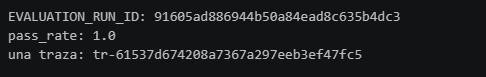

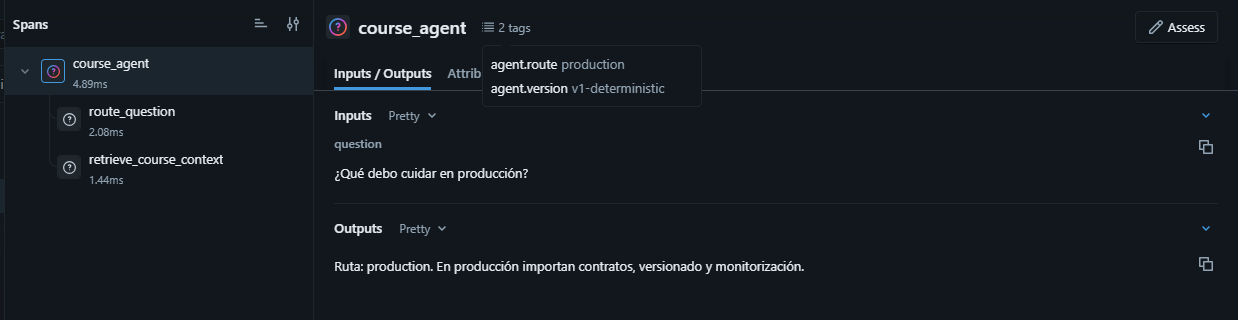